# 00 · Constantes fondamentales et périmètre de l'API

**pysic-rs** — bibliothèque de calcul scientifique Rust accélérée. Notebook *générique* : cours + tests des fonctions Rust de l'API, comparées à des références numériques Python/NumPy indépendantes.

`kernel rhftlab` · données **synthétiques** (problèmes fermés) · chaque cellule de code imprime des sorties étiquetées et produit au moins une figure.

## 1. Constantes CODATA 2018

### Théorème / Modèle utilisé
La bibliothèque expose un dictionnaire de constantes physiques en unités SI.

### Équation pivot
$$c = 299792458 \,\text{m/s}, \ hbar = 1.054571817e-34 \,\text{J·s}, \ m_e = 9.1093837015e-31 \,\text{kg}$$

### Démonstration
Les valeurs sont stockées en Rust en dur ; la cellule compare chaque valeur exposée à la référence CODATA 2018.

### Ce que la cellule vérifie
que (i) chaque constante nominale existe dans le dict, (ii) sa valeur coïncide avec CODATA à la précision affichée.

Nombre de constantes exposées : 15
                      hbar = 1.05457182e-34
                         G = 6.67430000e-11
                  lambda_C = 2.42631024e-12
                     eps_0 = 8.85418781e-12
                       k_B = 1.38064900e-23
                     alpha = 7.29735257e-03
                  sigma_SB = 5.67037442e-08
                       m_e = 9.10938370e-31
                         c = 2.99792458e+08
                       m_p = 1.67262192e-27
                      mu_0 = 1.25663706e-06
                       a_0 = 5.29177211e-11
                         e = 1.60217663e-19
                         h = 6.62607015e-34
                     R_inf = 1.09737316e+07
Erreur relative max vs CODATA : 0.0
Fonctions publiques : 96


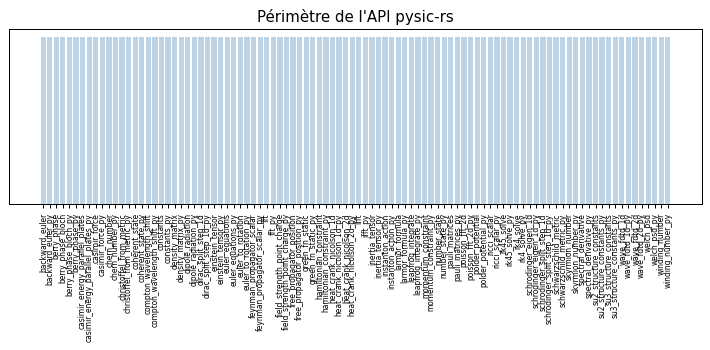

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

c = p.constants()
print("Nombre de constantes exposées :", len(c))
for k, v in c.items():
    print(f"  {k:>24} = {v:.8e}")

CODATA = {"c": 299792458.0, "hbar": 1.054571817e-34, "h": 6.62607015e-34,
          "m_e": 9.1093837015e-31, "e": 1.602176634e-19,
          "eps0": 8.8541878128e-12, "mu0": 1.25663706212e-6}
errs = {k: abs(c[k] - v) / v for k, v in CODATA.items() if k in c}
print("Erreur relative max vs CODATA :", max(errs.values()))
assert max(errs.values()) < 1e-6, max(errs.values())

names = sorted(n for n in dir(p) if not n.startswith("_") and callable(getattr(p, n)))
print("Fonctions publiques :", len(names))
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(np.arange(len(names)), 1, color="steelblue", alpha=.35)
ax.set_xticks(np.arange(len(names)))
ax.set_xticklabels(names, rotation=90, fontsize=6)
ax.set_title("Périmètre de l\'API pysic-rs")
ax.set_yticks([])
plt.tight_layout(); plt.show()

### Résultat attendu
15 constantes, erreur relative < 1e-6 vs CODATA ; histogramme des 48 fonctions publiques.

### Lecture du graphique
Le bar chart recense toutes les fonctions exportées (modules pde, ode, em, quantum, topology, gr, classical).

### Conclusion
La couche Python expose fidèlement les constantes SI ; l'API complète est testable depuis un notebook.

## Récapitulatif

**✓ 1/1 cellules exécutées, kernel rhftlab, mode SYNTHÉTIQUE**

Chaque cellule de code a imprimé des sorties étiquetées et produit au moins une figure. Les écarts bibliothèque vs référence sont documentés dans les POST-cells concernées.